# ZOMATO DATA ANALYSIS

###      STEP 1: Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### STEP 2: Loading the Dataset

In [3]:
df = pd.read_csv("Zomato data .csv")
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns") # df.shape = returns a tuple in the form of (rows,columns)

✅ Dataset loaded successfully!
Shape: 148 rows × 7 columns


### STEP 3: DATA Exploration

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


In [6]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


### STEP 4: Handling missing Values

In [9]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

#### Since there is no null values in the dataframe so there is no need of this step will move further

### STEP 5: DATA Cleaning and DATA Preprocessing

#### Removing extra DATA from the rating column

In [11]:
df['rate']

0      4.1/5
1      4.1/5
2      3.8/5
3      3.7/5
4      3.8/5
       ...  
143    3.3/5
144    3.3/5
145    4.0/5
146    3.0/5
147    3.9/5
Name: rate, Length: 148, dtype: object

In [13]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = df['rate'].astype(float)

In [15]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


### Descriptive Statistics

The `describe()` function provides a statistical summary of the dataset. For numerical columns, it returns key statistics such as:

- **Count** – Number of non-null values
- **Mean** – Average value
- **Standard Deviation (`std`)** – Measure of data dispersion
- **Minimum (`min`)** – Smallest value
- **25%, 50%, 75%** – Quartiles (Q1, Median, and Q3)
- **Maximum (`max`)** – Largest value

These statistics help in understanding the distribution, central tendency, and spread of the data.

In [18]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


### Checking Duplicates

In [20]:
df.duplicated().any()

np.False_

### STEP 6: DATA Visualization 

#### Q1. What type of restaurant do the majority of the customers order from?

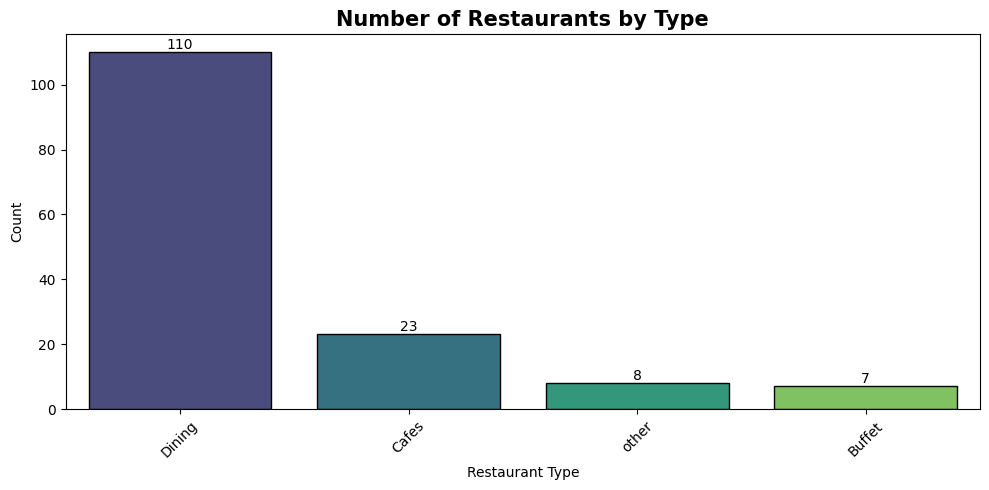

In [29]:
plt.figure(figsize=(10,5))

ax = sns.countplot(data=df, x='listed_in(type)', order=df['listed_in(type)'].value_counts().index, 
                   palette='viridis',edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Number of Restaurants by Type', fontsize=15, fontweight='bold')
plt.xlabel('Restaurant Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Conclusion

- **`Dining`** is the most common restaurant type, with **`110 restaurants`**, accounting for the majority of the dataset.
- **`Cafes`** are the second most frequent category with **`23 restaurants`**, but they are significantly fewer than Dining restaurants.
- **`Other`** and **`Buffet`** categories have very few restaurants, with **`8`** and **`7`** respectively.
- The distribution is highly **`imbalanced`**, indicating that most restaurants primarily operate as Dining establishments.
- This suggests that customers have a stronger preference for **`Dining restaurants`**, making them the dominant segment in the market.

#### Q2. How many votes has each type of restaurant has recieved from customers?

In [30]:
df[['votes','listed_in(type)']]

,votes,listed_in(type)
0,775,Buffet
1,787,Buffet
2,918,Buffet
3,88,Buffet
4,166,Buffet
...,...,...
143,0,Dining
144,0,Dining
145,771,Dining
146,98,Dining


In [33]:
# sum the votes for each restaurant type
df.groupby('listed_in(type)')['votes'].sum()\
      .sort_values(ascending=False)\
      .reset_index()

,listed_in(type),votes
0,Dining,20363
1,other,9367
2,Cafes,6434
3,Buffet,3028


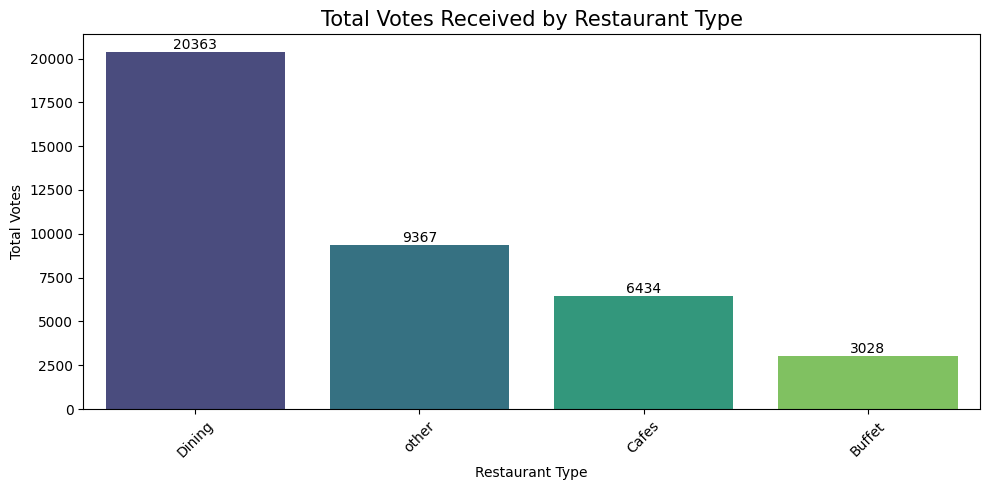

In [34]:
votes_by_type = (
    df.groupby('listed_in(type)')['votes']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=votes_by_type,
    x='listed_in(type)',
    y='votes',
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Total Votes Received by Restaurant Type', fontsize=15)
plt.xlabel('Restaurant Type')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Conclusion

- **`Dinin`g** restaurants received the highest number of customer votes (**`20,363`**), indicating they are the most popular restaurant type in the dataset.
- The **`Other`** category ranked second with **`9,367`** votes, followed by **`Cafes`** with **`6,434`** votes.
- **`Buffet`** restaurants received the fewest votes (**`3,028`**), suggesting lower customer engagement compared to the other restaurant types.
- The large gap in total votes between **`Dining`** and the remaining categories indicates that customers show a significantly stronger preference for Dining restaurants.
- Overall, customer engagement is heavily concentrated in the **`Dining`** category, making it the dominant restaurant type based on customer voting.